## Introduction

Calibrated simulation using semisynthetic data based on the OA dataset.

TODO: 

1. Engineer this so that I dont have to run all methods at once. Can choose which to run. 
2. More sophisticated grid search - this is important.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import importlib

import pickle

import sys
sys.path.append("../../")
import methods  
importlib.reload(methods)

from decision_rules import *

Error importing in API mode: ImportError("dlopen(/Users/timothysudijono/anaconda3/envs/eb/lib/python3.11/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /usr/lib/libpcre2-8.0.dylib\n  Referenced from: <20FB70DB-7E84-3375-A520-E0350E06C060> /Users/timothysudijono/anaconda3/envs/eb/lib/python3.11/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/usr/lib/libpcre2-8.0.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/usr/lib/libpcre2-8.0.dylib' (no such file), '/usr/lib/libpcre2-8.0.dylib' (no such file, not in dyld cache)")
Trying to import in ABI mode.


### Create Synthetic Dataset

We use NPMLE on the experimentation dataset and take the posterior means $\hat{\mu}_i$ as the true mus. Then a new synthetic dataset may be generate by taking $\tilde{Y}_i = \hat{\mu}_i + N(0,\sigma_i^2).$

In [2]:
test_df = pd.read_csv('data/compound_decisions_seed94301.csv')
test_df = test_df.dropna(subset = ["kfr_black_pooled_p25_se","kfr_black_pooled_p25"])
test_df.shape

(10056, 33)

In [3]:
np.random.seed(1)

sigmas = np.array(test_df.kfr_black_pooled_p25_se)
true_effects = np.array(test_df.kfr_black_pooled_p25)
costs = 0.361*np.ones(len(true_effects))
predictiveX = true_effects + 0.04*np.random.standard_t(10, len(true_effects))
noisyX = 0.1*np.random.standard_t(10, len(true_effects))
Xs = noisyX
#noisyX = 0.2*np.random.standard_t(10, len(true_effects))

In [ ]:
np.sum(np.maximum(0,true_effects - costs))

In [ ]:
plt.scatter(true_effects, Xs)
print(np.corrcoef(true_effects,Xs))

In [324]:
mc_runs = 40

results = {
    'naive_pval': np.zeros(mc_runs),
    'assure_pval': np.zeros(mc_runs),
    'cb_pval': np.zeros(mc_runs),
    'naive_trunc': np.zeros(mc_runs),
    'assure_trunc': np.zeros(mc_runs),
    'cb_trunc': np.zeros(mc_runs),
    'naive_linear_shrink': np.zeros(mc_runs),
    'assure_linear_shrink': np.zeros(mc_runs),
    'cb_linear_shrink': np.zeros(mc_runs),
    'npmle': np.zeros(mc_runs),
    'close_npmle': np.zeros(mc_runs),
    'close_gauss': np.zeros(mc_runs),
    'assure_close_gauss_cvx': np.zeros(mc_runs),
    'assure_close_gauss': np.zeros(mc_runs),
    'fh': np.zeros(mc_runs),
    'assure_fh': np.zeros(mc_runs),
    'cb_fh': np.zeros(mc_runs),
    'npmle': np.zeros(mc_runs),
    'assure_linear': np.zeros(mc_runs),
    'cb_linear': np.zeros(mc_runs)
}

In [ ]:
def generate_misspecified_bin_Ys(true_effects, sigmas):
    # pretend data is binomial; use number of observations such that mean of binomial is sigmas
    ns = (true_effects*(1-true_effects)/(sigmas**2)).astype(int)
    data = np.random.binomial(n = ns, p = true_effects)
    return data/ns

def generate_misspecified_t_Ys(true_effects, sigmas):
    return true_effects + sigmas*np.random.standard_t(10,len(true_effects))

In [327]:
for i in range(mc_runs):
    print(i)

    #Ys = true_effects + np.random.normal(0,sigmas)

    ### misspecified Ys
    Ys = generate_misspecified_t_Ys(true_effects,sigmas)


    ### p < 0.05 P-value Decision
    naive_decisions = get_naive_pval_decisions(Ys = Ys, 
                            sigmas = sigmas, 
                            costs = costs)

    results['naive_pval'][i] = np.sum((true_effects - costs)[np.where(naive_decisions)])
    

    ### ASSURE P-value Decision
    param_grid = np.linspace(-4,4,50)
    assure_decisions = get_assure_pval_decisions(Ys = Ys, 
                            sigmas = sigmas, 
                            costs = costs,
                            param_grid=param_grid[:,np.newaxis])

    results['assure_pval'][i] = np.sum((true_effects - costs)[np.where(assure_decisions)])

    ### CB P-value Decision
    param_grid = np.linspace(-4,4,50)
    cb_pval_decisions = get_cb_pval_decisions(Ys = Ys, 
                            sigmas = sigmas, 
                            costs = costs,
                            param_grid=param_grid[:,np.newaxis])

    results['cb_pval'][i] = np.sum((true_effects - costs)[np.where(cb_pval_decisions)])
    
    ### Naive Truncation (Greater than zero) Decision
    naive_truncation_decisions = get_naive_truncation_decisions(Ys = Ys, 
                            sigmas = sigmas, 
                            costs = costs)

    results['naive_trunc'][i] = np.sum((true_effects - costs)[np.where(naive_truncation_decisions)])


    ### ASSURE Truncation Decision
    param_grid = np.linspace(-0.1,0.1,50)
    assure_truncation_decisions = get_assure_truncation_decisions(Ys = Ys, 
                            sigmas = sigmas, 
                            costs = costs,
                            param_grid=param_grid[:,np.newaxis])

    results['assure_trunc'][i] = np.sum((true_effects - costs)[np.where(assure_truncation_decisions)])


    ### CB Truncation Decision
    param_grid = np.linspace(-0.1,0.1,50)
    cb_truncation_decisions = get_cb_truncation_decisions(Ys = Ys, 
                            sigmas = sigmas, 
                            costs = costs,
                            param_grid=param_grid[:,np.newaxis])

    results['cb_trunc'][i] = np.sum((true_effects - costs)[np.where(cb_truncation_decisions)])
    

    ### Naive Linear Shrinkage (Plug-in EB)
    naive_linear_shrinkage_decisions = get_naive_linear_shrinkage_decisions(Ys = Ys,
                                                                            sigmas=sigmas,
                                                                            costs=costs)
    results['naive_linear_shrink'][i] = np.sum((true_effects - costs)[np.where(naive_linear_shrinkage_decisions)])


    ### ASSURE Linear Shrinkage
    tau_vals = np.linspace(0.001, 0.2, 50)
    mu_0_vals = np.linspace(0, 1, 50)
    param_grid = np.stack(np.meshgrid(tau_vals, mu_0_vals, indexing="ij"), axis= -1).reshape(-1, 2)


    assure_linear_shrinkage_decisions = get_assure_linear_shrinkage_decisions(Ys = Ys,
                                                                            sigmas=sigmas,
                                                                            costs=costs,
                                                                            param_grid = param_grid)
    results['assure_linear_shrink'][i] = np.sum((true_effects - costs)[np.where(assure_linear_shrinkage_decisions)])


    cb_linear_shrinkage_decisions = get_cb_linear_shrinkage_decisions(Ys = Ys,
                                                                            sigmas=sigmas,
                                                                            costs=costs,
                                                                            param_grid = param_grid)
    results['cb_linear_shrink'][i] = np.sum((true_effects - costs)[np.where(cb_linear_shrinkage_decisions)])


    ### Linear Model
    C_vals = np.linspace(-2, 2, 50)
    b_vals = np.linspace(-2, 2, 50)
    param_grid = np.stack(np.meshgrid(C_vals, b_vals, indexing="ij"), axis= -1).reshape(-1, 2)

    assure_linear_decisions = get_assure_linear_decisions(Ys, sigmas, costs, noisyX, param_grid)
    results['assure_linear'][i] = np.sum((true_effects - costs)[np.where(assure_linear_decisions)])

    cb_linear_decisions = get_cb_linear_decisions(Ys, sigmas, costs, noisyX, param_grid)
    results['cb_linear'][i] = np.sum((true_effects - costs)[np.where(cb_linear_decisions)])

    ### ASSURE Close Gauss Model
    a1_vals = np.linspace(-1, 1, 10)
    a2_vals = np.linspace(0, 1, 10)
    b1_vals = np.linspace(-10, 0, 10)
    b2_vals = np.linspace(-2, 2, 10)

    g = np.meshgrid(a1_vals, a2_vals, b1_vals, b2_vals, indexing="ij")
    param_grid = np.stack(g, axis= -1).reshape(-1, 4)

    close_gauss_decisions = get_close_gauss_decisions(Ys, sigmas, costs, param_grid)

    results['assure_close_gauss'][i] = np.sum((true_effects - costs)[np.where(close_gauss_decisions)])


    ### NPMLE Decisions
    npmle_decisions, npmle_posterior_means = get_npmle_decisions(Ys, sigmas, costs)
    results['npmle'][i] = np.sum((true_effects - costs)[np.where(npmle_decisions)])

    ### CLOSE NPMLE Decisions
    close_results = methods.CLOSE(Ys, sigmas)

    close_npmle_posterior_means = close_results[1]
    close_npmle_decisions = (close_npmle_posterior_means >= costs).astype(int)
    results['close_npmle'][i] = np.sum((true_effects - costs)[np.where(close_npmle_decisions)])

    ### CLOSE-GAUSS
    close_gauss_posterior_means = close_results[0]
    close_gauss_decisions = (close_gauss_posterior_means >= costs).astype(int)
    results['close_gauss'][i] = np.sum((true_effects - costs)[np.where(close_gauss_decisions)])

    ### 1D CLOSE-Gauss Combination
    param_grid = np.linspace(0.01,0.99,100)
    m0 = close_results[2]
    s0_sq = close_results[3]**2


    Xs_aug = np.vstack((Xs, np.ones(len(Xs)))).T
    beta = methods.get_GLS_beta(Ys,Xs_aug,sigmas)

    fhat_X = (Xs_aug @ beta).reshape(-1,)

    decisions, welfare, opt_param = get_assure_1dcvx_combination_decisions(Ys,
                                                                            sigmas,
                                                                            costs,
                                                                            fhat_X,
                                                                            s0_sq=s0_sq,
                                                                            m0 = m0,
                                                                            param_grid=param_grid.reshape(-1,1))
    
    results['assure_close_gauss_cvx'][i] = np.sum((true_effects - costs)[np.where(decisions)])

    ### Fay Heriott Methods
    fh_decisions, fh_posterior_means = get_fay_heriott_decisions(Ys, sigmas, costs, Xs.reshape(-1,1))
    results['fh'][i] = np.sum((true_effects - costs)[np.where(fh_decisions)])

    A_vals = np.linspace(0.001, 0.2, 100)
    beta_vals = np.linspace(-2, 2, 50)
    param_grid = np.stack(np.meshgrid(A_vals, beta_vals, indexing="ij"), axis= -1).reshape(-1, 2)

    assure_fh_decisions = get_assure_fh_decisions(Ys, sigmas, costs, Xs.reshape(-1,1), param_grid)
    results['assure_fh'][i] = np.sum((true_effects - costs)[np.where(assure_fh_decisions)])

    cb_fh_decisions = get_cb_fh_decisions(Ys, sigmas, costs, Xs.reshape(-1,1), param_grid)
    results['cb_fh'][i] = np.sum((true_effects - costs)[np.where(cb_fh_decisions)])
    

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39


In [362]:
import pickle

# fname = f'../results/oa_analysis/OA_comparison_misspecified_mc_runs{mc_runs}_cost{costs[0]}_purenoiseX.pkl'

# with open(fname, 'wb') as f:
#    pickle.dump(results, f)

load_name = f'../results/oa_analysis/OA_comparison_misspecified_mc_runs{mc_runs}_cost{costs[0]}_goodX.pkl'

with open(load_name, 'rb') as f:
   results = pickle.load(f)

In [363]:
method_names =  {
    'naive_pval': '$p < 0.05$',
    'assure_pval': 'ASSURE $p$-val',
    'cb_pval': 'CB $p$-val',
    'naive_trunc': '$Y_i > 0$',
    'assure_trunc': 'ASSURE thresh',
    'cb_trunc': 'CB thresh',
    'naive_linear_shrink': 'Plug-in Shrinkage',
    'assure_linear_shrink': 'ASSURE Shrinkage',
    'cb_linear_shrink': 'CB Shrinkage',
    'npmle': 'NPMLE',
    'close_npmle': 'CLOSE-NPMLE',
    'close_gauss': 'CLOSE Gauss',
    'assure_close_gauss_cvx': 'ASSURE Interpolation',
    'assure_close_gauss': 'ASSURE Close-Gauss',
    'assure_linear': 'ASSURE Linear',
    'cb_linear': 'CB Linear',
    'fh': 'Fay-Heriott (FH)',
    'assure_fh': 'ASSURE FH',
    'cb_fh': 'CB FH'
}

plotted_methods = [
#    'naive_pval',
#    'assure_pval',
#    'cb_pval',
#    'naive_trunc',
#    'assure_trunc',
#    'cb_trunc',
    'naive_linear_shrink',
    'assure_linear_shrink',
    'cb_linear_shrink',
    'npmle',
    'close_npmle',
    'close_gauss',
    'assure_close_gauss_cvx',
#    'assure_linear',
#    'cb_linear',
    'assure_close_gauss',
    'fh',
    'assure_fh',
    'cb_fh'
]


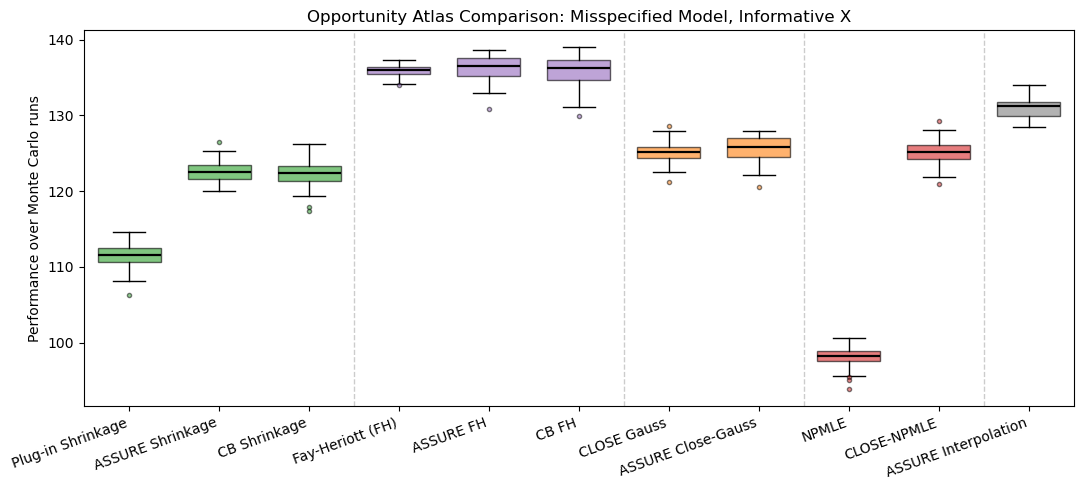

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def group_of(name: str) -> str:
    if name.endswith("pval"): return "pval"
    if name.endswith("trunc"): return "trunc"
    if name.endswith("shrink"): return "shrink"
    if name.endswith("linear"): return "linear"
    if name.endswith("fh"): return "fh"
    if name.endswith("gauss"): return "gauss"
    if name.endswith("npmle"): return "npmle"
    return "other"

group_colors = {
#    "pval": "tab:blue",
#    "trunc": "tab:orange",
    "shrink": "tab:green",
    "gauss": "tab:orange",
    "fh": "tab:purple",
    "npmle": "tab:red",
    "other": "tab:gray",
}


# order methods by group (pval, trunc, linear_shrink, other)
labels_all = plotted_methods
group_order = {"pval": 0, "trunc": 1, "shrink": 2, "linear": 3, "fh":4, "gauss":5, "npmle":6, "other": 7}
order = np.argsort([group_order[group_of(k)] for k in labels_all])

labels = [labels_all[i] for i in order]
data   = [np.asarray(results[k]) for k in labels]
colors = [group_colors[group_of(k)] for k in labels]
groups = [group_of(k) for k in labels]

# positions and plotting
x = np.arange(1, len(labels) + 1)
plt.figure(figsize=(11, 5))
bp = plt.boxplot(
    data,
    positions=x,
    widths=0.7,
    patch_artist=True,
    showfliers=False,   # show outliers
    whis=1.5           # standard Tukey whiskers
)

# color each box (and style whiskers, caps, medians, fliers)
for i in range(len(labels)):
    c = colors[i]
    plt.setp(bp['boxes'][i], facecolor=c, edgecolor='black', alpha=0.6, linewidth=1)
    plt.setp(bp['medians'][i], color='black', linewidth=1.6)
    plt.setp(bp['whiskers'][2*i],   color='black', linewidth=1)
    plt.setp(bp['whiskers'][2*i+1], color='black', linewidth=1)
    plt.setp(bp['caps'][2*i],   color='black', linewidth=1)
    plt.setp(bp['caps'][2*i+1], color='black', linewidth=1)
    # fliers (outliers)
    if len(bp['fliers']) > i:
        plt.setp(bp['fliers'][i], marker='o', markersize=3, markerfacecolor=c, markeredgecolor='black', alpha=0.5)

# x-axis labels
plt.xticks(x, [method_names[labels_all[i]] for i in order], rotation=20, ha="right")
plt.ylabel("Performance over Monte Carlo runs")
plt.title("Method Performance: Box-and-Whisker by Method (group-colored)")

# vertical separators between groups
boundaries = [i for i in range(1, len(groups)) if groups[i] != groups[i-1]]
for b in boundaries:
    plt.axvline(b + 0.5, color='0.8', linewidth=1, linestyle='--', zorder=0)

# legend from present groups
present_groups = []
for g in groups:
    if g not in present_groups:
        present_groups.append(g)
legend_handles = [Patch(facecolor=group_colors[g], edgecolor='black', label=g, alpha=0.6) for g in present_groups]
#plt.legend(handles=legend_handles, title="Group", frameon=True)

plt.tight_layout()
plt.title('Opportunity Atlas Comparison: Misspecified Model, Informative X')
plt.savefig(f'../results/oa_analysis/figures/OA_comparison_misspecified_mc_runs{mc_runs}_cost{costs[0]}_goodX.pdf', bbox_inches='tight')
#plt.savefig(f'../results/oa_analysis/figures/OA_comparison_normal_mc_runs{mc_runs}_cost{costs[0]}_goodX.pdf', bbox_inches='tight')
plt.show()
